In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [4]:
import pandas as pd

df = pd.read_csv("cleaned_complaints.csv")

df.head()

,message,label,clean_message
0,Payment taken multiple times! kindly resolve,2,payment taken multiple time kindly resolve
1,Serious complaint: wrong person received my or...,2,serious complaint wrong person received order ...
2,Need help with changing my address.,1,need help changing address
3,Urgent: money deducted but order failed! pleas...,2,urgent money deducted order failed please help
4,Your staff was polite. please help,0,staff polite please help


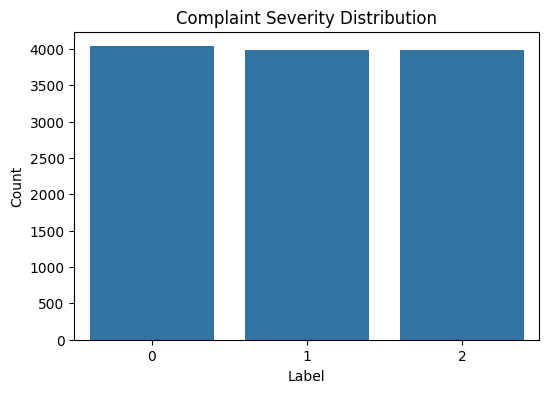

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Complaint Severity Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [6]:
df['label'].value_counts()

label
0    4033
2    3987
1    3980
Name: count, dtype: int64

In [7]:
df['message_length'] = df['clean_message'].apply(len)

df['message_length'].describe()

count    12000.000000
mean        32.580583
std         11.285121
min         12.000000
25%         24.000000
50%         31.000000
75%         39.000000
max         67.000000
Name: message_length, dtype: float64

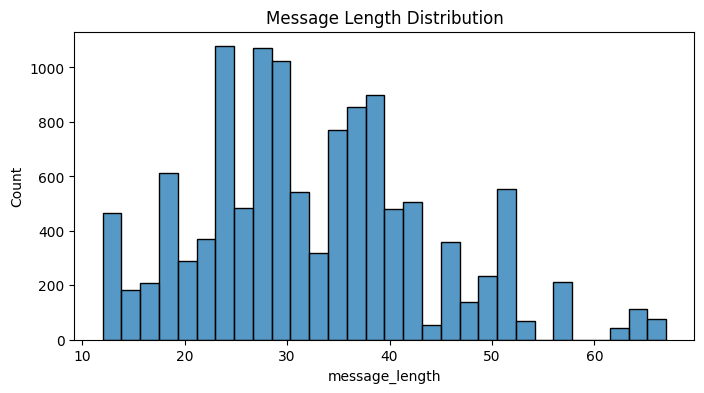

In [8]:
plt.figure(figsize=(8,4))

sns.histplot(df['message_length'], bins=30)

plt.title("Message Length Distribution")

plt.show()

In [9]:
all_words = " ".join(df['clean_message'])

word_list = all_words.split()

word_freq = Counter(word_list)

word_freq.most_common(20)

[('help', 3578),
 ('please', 2941),
 ('kindly', 2396),
 ('resolve', 2396),
 ('asap', 2172),
 ('payment', 1475),
 ('order', 1303),
 ('account', 1143),
 ('received', 1067),
 ('nice', 942),
 ('feedback', 869),
 ('info', 796),
 ('need', 571),
 ('changing', 571),
 ('address', 571),
 ('urgent', 569),
 ('money', 569),
 ('deducted', 569),
 ('failed', 569),
 ('taken', 560)]

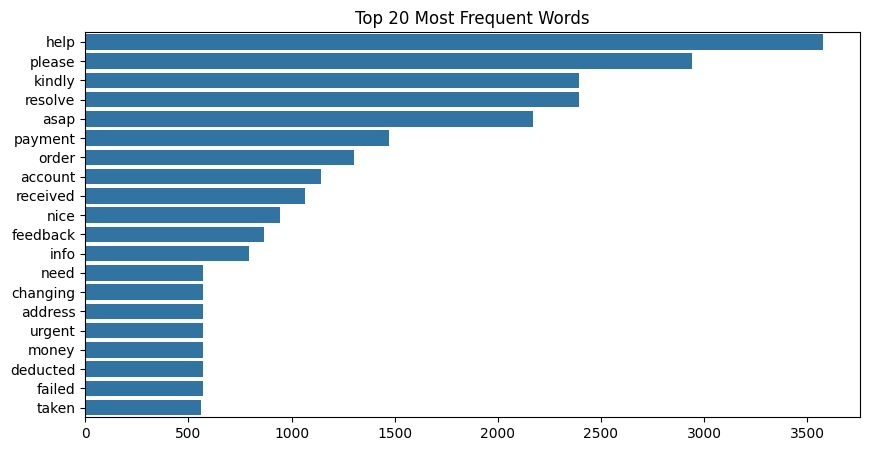

In [10]:
top_words = word_freq.most_common(20)

words = [word[0] for word in top_words]
counts = [word[1] for word in top_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words")

plt.show()

In [11]:
!pip install wordcloud


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from wordcloud import WordCloud

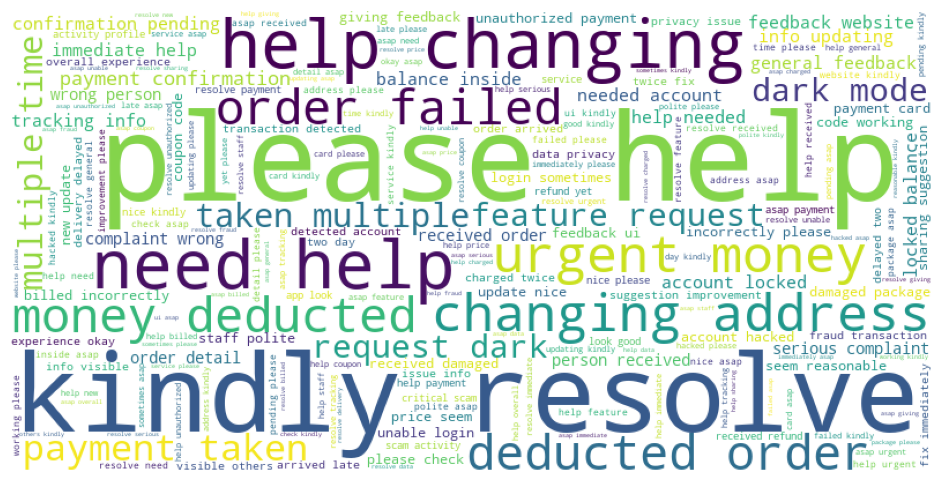

In [13]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()